In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  1.. Data Collection !

In [2]:
import os
working_directory = os.getcwd()

In [3]:
print(working_directory)

/Users/sameersuman/Documents/StockMarketAnalysis


In [4]:
path = working_directory + '/individual_stocks_5yr/*csv'

In [6]:
import glob

In [7]:
glob.glob(path)

['/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/XRX_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/GS_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/SPGI_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/MTB_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/V_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/CTAS_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/ESRX_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/APH_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/BBT_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/RHI_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/GGP_data.csv',
 '/Users/sameersuman/Documents/S

In [9]:
len(glob.glob(path)) ## total files we have 

505

In [ ]:
# lets store filesof those stock that we have to consider for analysis ..

In [10]:
company_list = [
   working_directory + '/individual_stocks_5yr/AAPL_data.csv' , 
   working_directory + '/individual_stocks_5yr/AMZN_data.csv' , 
   working_directory + '/individual_stocks_5yr/GOOG_data.csv' , 
    working_directory + '/individual_stocks_5yr/MSFT_data.csv'  
]

In [13]:
## use Warnings package to get rid of any future warning ..

import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
## Combine data from multiple sources into a single dataset

In [15]:
all_data = pd.DataFrame()

for file in company_list:
    
    current_df = pd.read_csv(file)

    # The commented line was actually the correct approach
    all_data = pd.concat([current_df, all_data], ignore_index=True)  

In [16]:
all_data.shape ## dimensions of all_data dataframe ..

(4752, 7)

In [17]:
all_data.head() ## top 5 rows of all_data dataframe ..

,date,open,high,low,close,volume,Name
0,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [18]:
all_data['Name'].unique()

array(['MSFT', 'GOOG', 'AMZN', 'AAPL'], dtype=object)

## DATA CLEANING & PREPARATIONS

In [19]:
all_data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')

In [20]:
all_data.dtypes

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object

In [21]:
all_data['date'] = pd.to_datetime(all_data['date']) ## convert date column to datetime format ..

In [22]:
all_data.dtypes

date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name              object
dtype: object

In [23]:
all_data['date']

0      2013-02-08
1      2013-02-11
2      2013-02-12
3      2013-02-13
4      2013-02-14
          ...    
4747   2018-02-01
4748   2018-02-02
4749   2018-02-05
4750   2018-02-06
4751   2018-02-07
Name: date, Length: 4752, dtype: datetime64[ns]

In [24]:
all_data.isnull().sum() ## check for null values in all_data dataframe ..

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [25]:
all_data.duplicated().sum() ## check for duplicate values in all_data dataframe ..

np.int64(0)

In [27]:
df=all_data['volume']<0 ## check for negative values in volume column of all_data dataframe ..

In [28]:
all_data[df] ## display rows where volume is negative ..

,date,open,high,low,close,volume,Name


In [29]:
tech_list = all_data['Name'].unique()

In [30]:
tech_list

array(['MSFT', 'GOOG', 'AMZN', 'AAPL'], dtype=object)

In [31]:
all_data = all_data.sort_values(by=['Name', 'date']) ## sort all_data dataframe by Name and date column in ascending order ..

## EDA
## 2.TIME SERIES ANALYSIS
## Analysing change in price of the stock overtime !

In [32]:
all_data

,date,open,high,low,close,volume,Name
3493,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
3494,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
3495,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3496,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
3497,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
...,...,...,...,...,...,...,...
1254,2018-02-01,94.7900,96.0700,93.5813,94.2600,47227882,MSFT
1255,2018-02-02,93.6400,93.9700,91.5000,91.7800,47867753,MSFT
1256,2018-02-05,90.5600,93.2400,88.0000,88.0000,51031465,MSFT
1257,2018-02-06,86.8900,91.4750,85.2500,91.3300,67998564,MSFT


In [ ]:
## which is the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ?

In [ ]:
all_data["daily_return"]=all_data.groupby('Name')['close'].pct_change() ## calculate daily return for each stock by taking percentage change of close price ..


In [37]:
risk = all_data.groupby('Name')['daily_return'].std() ## calculate standard deviation of daily return for each stock to measure volatility ..

In [38]:
risk.sort_values() ## sort risk values in ascending order to find the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ..

Name
GOOG    0.014069
MSFT    0.014210
AAPL    0.014593
AMZN    0.018235
Name: daily_return, dtype: float64

In [40]:
safest_stock = risk.idxmin() ## find the stock with minimum risk value to identify the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ..

In [42]:
safest_stock

'GOOG'

## 3. TOTAL RETURN ANALYSIS
## Which stock made the highest money?

In [44]:
## Calculate total return for each stock (from first day to last day)
total_returns = {}

for stock in tech_list:
    stock_data = all_data[all_data['Name'] == stock].sort_values('date')
    first_price = stock_data['close'].iloc[0]
    last_price = stock_data['close'].iloc[-1]
    total_return = ((last_price - first_price) / first_price) * 100
    total_returns[stock] = total_return

# Display results sorted by total return (highest first)
sorted_returns = sorted(total_returns.items(), key=lambda x: x[1], reverse=True)

print("="*50)
print("TOTAL RETURN BY STOCK (5-Year Period)")
print("="*50)
for stock, return_pct in sorted_returns:
    print(f"{stock}: {return_pct:+.2f}%")

best_stock = sorted_returns[0][0]
best_return = sorted_returns[0][1]
print("="*50)
print(f"\n✓ {best_stock} made the highest money with a {best_return:.2f}% return!")

TOTAL RETURN BY STOCK (5-Year Period)
AMZN: +440.86%
MSFT: +225.26%
AAPL: +135.12%
GOOG: +87.76%

✓ AMZN made the highest money with a 440.86% return!


4.Which stock made the highest money??

In [45]:
all_data["cumulative_return"] = (1+all_data["daily_return"]).groupby(all_data['Name']).cumprod() ## calculate cumulative return for each stock by taking cumulative product of (1 + daily return) for each stock ..

In [ ]:
final_returns = all_data.groupby('Name')["cumulative_return"].last() ## get the last value of cumulative return for each stock to find the total cumulative return for each stock over the 5 year period ..

final_returns.sort_values(ascending=False) ## sort final returns in descending order to find the stock with highest cumulative return over the 5 year period ..

Name
AMZN    5.408589
MSFT    3.252632
AAPL    2.351218
GOOG    1.877628
Name: cumulative_return, dtype: float64

In [51]:
best_stock = final_returns.idxmax()
best_stock

'AMZN'

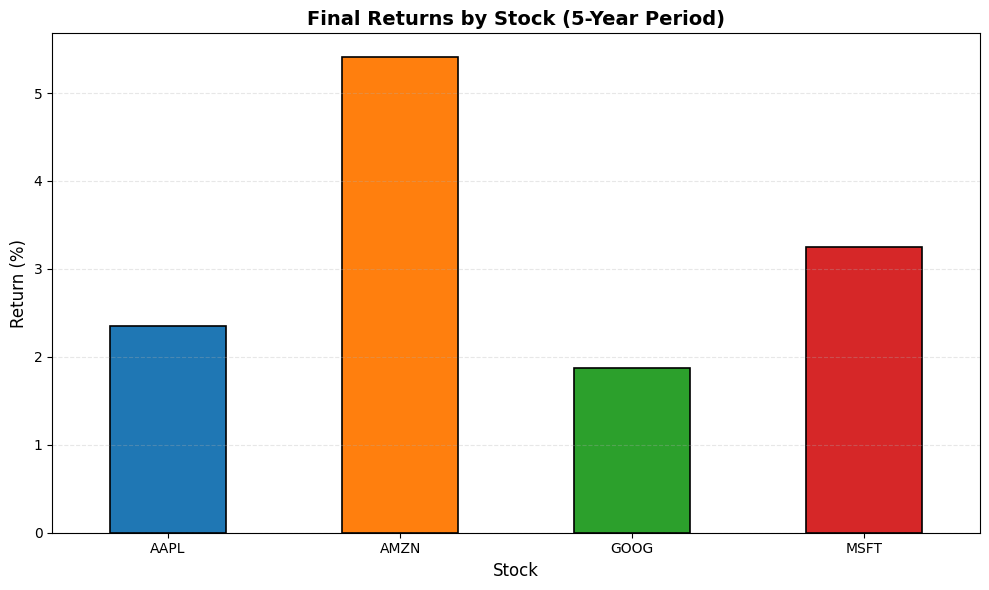

In [ ]:
## Plot bar chart of final returns (ascending order)
plt.figure(figsize=(10, 6))
final_returns.sort_values().plot(kind='bar', color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], edgecolor='black', linewidth=1.2)
plt.title('Final Returns by Stock (5-Year Period) - Ascending Order', fontsize=14, fontweight='bold')
plt.xlabel('Stock', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()